# Étape 2 — Prétraitement et extraction de features (BrainScanAI)

**Objectif** : Préparer les images (resize, normalisation ImageNet) et utiliser ResNet50 pré-entraîné pour extraire des embeddings visuels à deux niveaux d'abstraction (`layer3` → 1024D, `avgpool` → 2048D).

**Entrée** : 1506 images (1406 sans label + 100 étiquetées)  
**Sortie** : `data/features.npz` + `data/features_meta.csv`

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm

from sklearn.manifold import TSNE

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path("../data")
SANS_LABEL_DIR = DATA_DIR / "sans_label"
CANCER_DIR = DATA_DIR / "avec_labels" / "cancer"
NORMAL_DIR = DATA_DIR / "avec_labels" / "normal"

BATCH_SIZE = 32
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

Device : mps


## 1. Dataset custom avec preprocessing ImageNet

In [47]:
# Transform pipeline : resize → center crop → tensor → normalize (ImageNet stats)
imagenet_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


class BrainDataset(Dataset):
    def __init__(self, records, transform):
        # records : list of dict {"path": Path, "label": str|None, "split": str}
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        img = Image.open(rec["path"]).convert("RGB")
        return self.transform(img), idx


# Construire la liste de records
records = []
for path in sorted(SANS_LABEL_DIR.glob("*.jpg")):
    records.append({"path": str(path), "label": None, "split": "unlabeled"})
for path in sorted(CANCER_DIR.glob("*.jpg")):
    records.append({"path": str(path), "label": "cancer", "split": "labeled"})
for path in sorted(NORMAL_DIR.glob("*.jpg")):
    records.append({"path": str(path), "label": "normal", "split": "labeled"})

dataset = BrainDataset(records, imagenet_transform)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Total images : {len(dataset)}")
print(f"  Sans label : {sum(1 for r in records if r['split'] == 'unlabeled')}")
print(f"  Avec label : {sum(1 for r in records if r['split'] == 'labeled')}")

Total images : 1506
  Sans label : 1406
  Avec label : 100


## 2. Chargement de ResNet50 pré-entraîné — couches gelées

In [48]:
# Charger ResNet50 pré-entraîné
resnet = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

# print(resnet.layer3.parameters)

# Geler toutes les couches convolutionnelles
for param in resnet.parameters():
    param.requires_grad = False

resnet = resnet.to(device)
resnet.eval()

# Buffers pour les hooks
hook_outputs = {}

def make_hook(name):
    def hook(module, input, output):
        hook_outputs[name] = output.detach()
    return hook

resnet.layer2.register_forward_hook(make_hook("layer2"))
resnet.layer3.register_forward_hook(make_hook("layer3"))
resnet.avgpool.register_forward_hook(make_hook("avgpool"))

# Adaptive pooling pour réduire layer3 (B,1024,14,14) → (B,1024)
gap = nn.AdaptiveAvgPool2d((1, 1)).to(device)

print("ResNet50 chargé — couches gelées — hooks enregistrés sur layer2, layer3 et avgpool")
trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
total = sum(p.numel() for p in resnet.parameters())
print(f"Paramètres : {total:,} total, {trainable} entraînables")

ResNet50 chargé — couches gelées — hooks enregistrés sur layer2, layer3 et avgpool
Paramètres : 25,557,032 total, 0 entraînables


## 3. Extraction des features

In [49]:
n = len(dataset)
features_layer2 = np.zeros((n, 512), dtype=np.float32)
features_layer3 = np.zeros((n, 1024), dtype=np.float32)
features_avgpool = np.zeros((n, 2048), dtype=np.float32)

with torch.no_grad():
    for batch_imgs, batch_idx in tqdm(loader, desc="Extraction features"):
        batch_imgs = batch_imgs.to(device)
        _ = resnet(batch_imgs)  # forward pass déclenche les hooks

        # layer2 : (B, 512, 14, 14) → GAP → (B, 512)
        l2 = gap(hook_outputs["layer2"]).squeeze(-1).squeeze(-1).cpu().numpy()
        # layer3 : (B, 1024, 14, 14) → GAP → (B, 1024)
        l3 = gap(hook_outputs["layer3"]).squeeze(-1).squeeze(-1).cpu().numpy()
        # avgpool : (B, 2048, 1, 1) → flatten → (B, 2048)
        ap = hook_outputs["avgpool"].squeeze(-1).squeeze(-1).cpu().numpy()

        idx = batch_idx.numpy()
        features_layer2[idx] = l2
        features_layer3[idx] = l3
        features_avgpool[idx] = ap

print(f"layer2  features : {features_layer2.shape}")
print(f"layer3  features : {features_layer3.shape}")
print(f"avgpool features : {features_avgpool.shape}")

Extraction features: 100%|██████████| 48/48 [00:08<00:00,  5.97it/s]

layer2  features : (1506, 512)
layer3  features : (1506, 1024)
avgpool features : (1506, 2048)


## 4. Sauvegarde

In [50]:
np.savez(
    DATA_DIR / "features.npz",
    avgpool=features_avgpool,
)

meta_df = pd.DataFrame(records)
meta_df.to_csv(DATA_DIR / "features_meta.csv", index=False)

print("Sauvegardé :")
print(f"  data/features.npz  — avgpool: {features_avgpool.shape}")
print(f"  data/features_meta.csv — {len(meta_df)} lignes")
print(meta_df.head())

Sauvegardé :
  data/features.npz  — avgpool: (1506, 2048)
  data/features_meta.csv — 1506 lignes
                                                path label      split
0  ../data/sans_label/001b158a-7af8-451e-bf31-3a9...   NaN  unlabeled
1  ../data/sans_label/00366e8d-5520-4d3c-a70b-91a...   NaN  unlabeled
2  ../data/sans_label/00455a62-f79f-4072-9a23-495...   NaN  unlabeled
3  ../data/sans_label/004ce5f5-ca6b-490f-9b2f-c32...   NaN  unlabeled
4  ../data/sans_label/005d9a37-8894-4eb5-8367-101...   NaN  unlabeled


## 5. Vérification et visualisation (t-SNE avec avgpool)

t-SNE sur un sous-ensemble de 300 images pour vérifier que les features séparent déjà les classes.

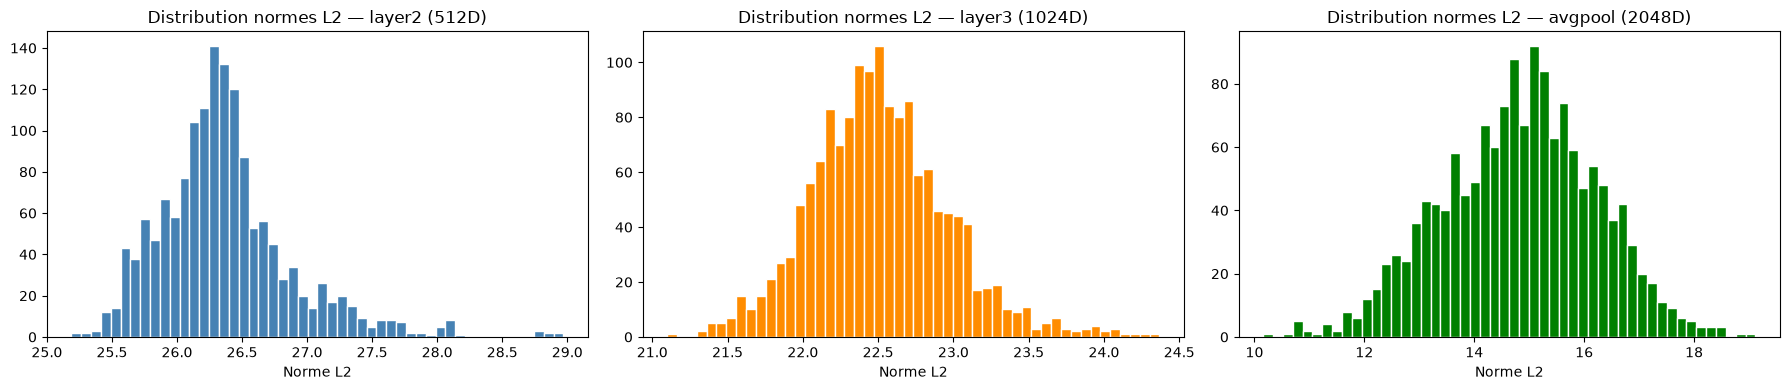

layer2  norme — min: 25.19, max: 28.97, moy: 26.37
layer3  norme — min: 21.10, max: 24.37, moy: 22.51
avgpool norme — min: 10.16, max: 19.12, moy: 14.81


In [51]:
# Sanity check : distribution des normes L2
norms_l2 = np.linalg.norm(features_layer2, axis=1)
norms_l3 = np.linalg.norm(features_layer3, axis=1)
norms_ap = np.linalg.norm(features_avgpool, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(norms_l2, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution normes L2 — layer2 (512D)")
axes[0].set_xlabel("Norme L2")
axes[1].hist(norms_l3, bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("Distribution normes L2 — layer3 (1024D)")
axes[1].set_xlabel("Norme L2")
axes[2].hist(norms_ap, bins=50, color="green", edgecolor="white")
axes[2].set_title("Distribution normes L2 — avgpool (2048D)")
axes[2].set_xlabel("Norme L2")
plt.tight_layout()
plt.show()

print(f"layer2  norme — min: {norms_l2.min():.2f}, max: {norms_l2.max():.2f}, moy: {norms_l2.mean():.2f}")
print(f"layer3  norme — min: {norms_l3.min():.2f}, max: {norms_l3.max():.2f}, moy: {norms_l3.mean():.2f}")
print(f"avgpool norme — min: {norms_ap.min():.2f}, max: {norms_ap.max():.2f}, moy: {norms_ap.mean():.2f}")

**Interprétation :** Les trois histogrammes montrent la distribution des normes L2 des features extraites à trois niveaux du réseau ResNet50 pour l'ensemble des 1 506 images.

- **layer2 (512D)** — normes concentrées entre 25,2 et 29,0 (moy. 26,4) : distribution très resserrée, quasi-gaussienne. Les features précoces sont homogènes — elles capturent des textures bas-niveau similaires pour toutes les images (bords, contrastes locaux), sans discrimination entre classes.
- **layer3 (1024D)** — normes entre 21,1 et 24,4 (moy. 22,5) : distribution légèrement plus étroite en valeur absolue, ce qui s'explique par la normalisation interne des blocs résiduels. La faible dispersion indique là encore une représentation homogène à ce niveau d'abstraction intermédiaire.
- **avgpool (2048D)** — normes entre 10,2 et 19,1 (moy. 14,8) : distribution nettement plus étalée. Cet étalement reflète une plus grande variabilité sémantique entre images — les features globales de haut niveau (après le dernier bloc résiduel) capturent mieux les différences de contenu entre images, ce qui est favorable à la discrimination cancer/normal.

**Conclusion :** L'absence de valeurs nulles ou aberrantes confirme que l'extraction s'est déroulée sans effondrement numérique. La dispersion croissante de layer2 vers avgpool est cohérente avec la hiérarchie des réseaux convolutifs : plus on monte dans le réseau, plus les features sont discriminantes. C'est pourquoi `avgpool` (2048D) a été retenu pour le clustering et le transfert de learning.

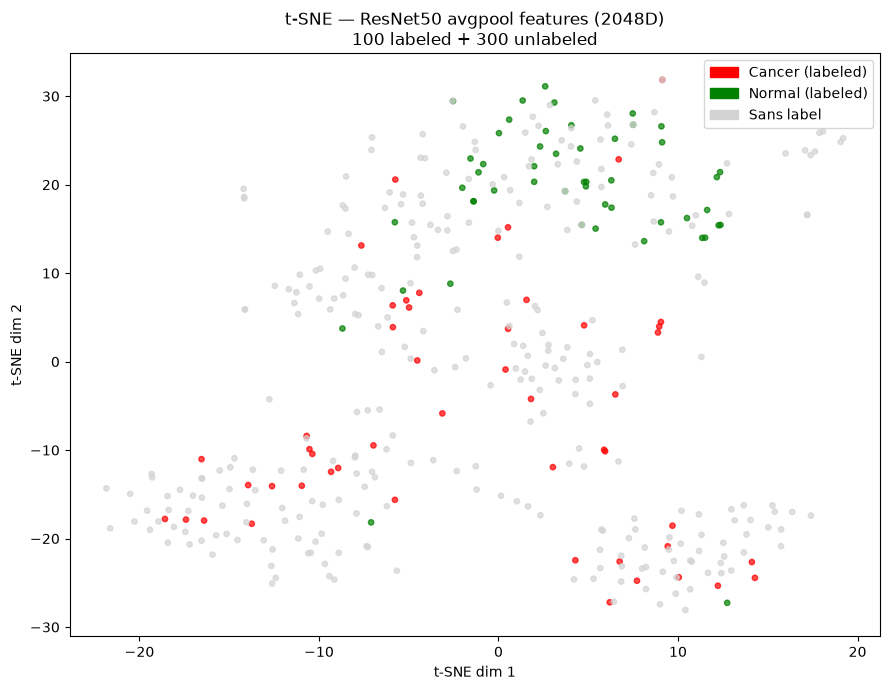

In [52]:
import random
random.seed(SEED)

# Indices des images étiquetées (toutes les 100) et 300 non-étiquetées aléatoires
labeled_idx = [i for i, r in enumerate(records) if r["split"] == "labeled"]
unlabeled_idx = [i for i, r in enumerate(records) if r["split"] == "unlabeled"]
sample_unlabeled = random.sample(unlabeled_idx, 300)
viz_idx = np.array(labeled_idx + sample_unlabeled)

# t-SNE sur avgpool features
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
X_tsne_ap = tsne.fit_transform(features_avgpool[viz_idx])

# Colorier : cancer=rouge, normal=vert, unlabeled=gris
colors = []
for i in viz_idx:
    label = records[i]["label"]
    if label == "cancer":
        colors.append("red")
    elif label == "normal":
        colors.append("green")
    else:
        colors.append("lightgray")

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_tsne_ap[:, 0], X_tsne_ap[:, 1], c=colors, s=15, alpha=0.7)

from matplotlib.patches import Patch
legend = [
    Patch(color="red", label="Cancer (labeled)"),
    Patch(color="green", label="Normal (labeled)"),
    Patch(color="lightgray", label="Sans label"),
]
ax.legend(handles=legend, loc="best")
ax.set_title("t-SNE — ResNet50 avgpool features (2048D)\n100 labeled + 300 unlabeled")
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
plt.tight_layout()
plt.show()

**Interprétation :** Le t-SNE projette en 2D les 2 048 dimensions des features `avgpool` extraites par ResNet50 (pré-entraîné ImageNet). Chaque point représente une image ; la couleur indique le statut (rouge = cancer, vert = normal, gris clair = sans label).

- **Séparation partielle des classes étiquetées** : les points rouges et verts ne forment pas deux îlots parfaitement distincts, ce qui est attendu — ResNet50 n'a pas été entraîné sur des IRM cérébrales. Malgré cela, on observe une tendance à la structuration : certaines zones du manifold concentrent davantage de points cancer ou normal, signe que les features ImageNet capturent une partie de la variabilité visuelle pertinente pour ce domaine.
- **Distribution des images sans label** : les points gris se répartissent sur l'ensemble du nuage, sans région totalement isolée. Cela indique que les 1 406 images sans label occupent le même espace de features que les images étiquetées — condition favorable au transfert de labels par clustering ou pseudo-labellisation.
- **Stabilité des normes L2** : les normes `avgpool` varient de 10,2 à 19,1 (moy. 14,8), sans valeur aberrante ni effondrement — les features sont exploitables telles quelles pour les étapes suivantes.

En résumé, bien que la séparation ne soit pas nette (ce qui explique l'ARI modéré observé à l'étape 3), les features ResNet50 fournissent un signal discriminant suffisant pour servir de point de départ au transfert de learning et à l'apprentissage semi-supervisé.

## 6. Comparaison layer3 vs avgpool (t-SNE côte-à-côte)

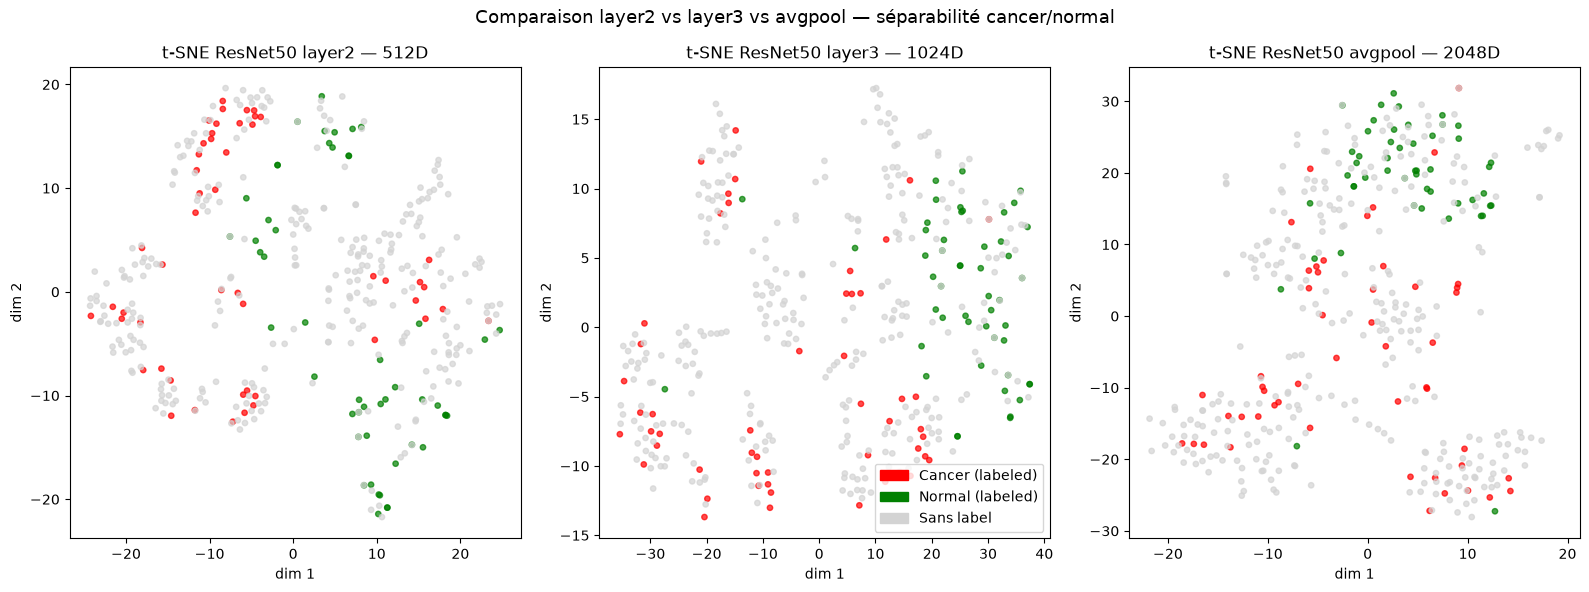

In [53]:
# t-SNE sur layer3 features (mêmes indices)
tsne2 = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
X_tsne_l2 = tsne2.fit_transform(features_layer2[viz_idx])
X_tsne_l3 = tsne2.fit_transform(features_layer3[viz_idx])
X_tsne_ap = tsne2.fit_transform(features_avgpool[viz_idx])

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, X, title in [
    (axes[0], X_tsne_l2, "layer2 — 512D"),
    (axes[1], X_tsne_l3, "layer3 — 1024D"),
    (axes[2], X_tsne_ap, "avgpool — 2048D"),
]:
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=15, alpha=0.7)
    ax.set_title(f"t-SNE ResNet50 {title}")
    ax.set_xlabel("dim 1")
    ax.set_ylabel("dim 2")

axes[1].legend(handles=legend, loc="best")
plt.suptitle("Comparaison layer2 vs layer3 vs avgpool — séparabilité cancer/normal", fontsize=13)
plt.tight_layout()
plt.show()

## Observations et conclusions

### Features extraites
- **layer3 (1024D)** : features intermédiaires, plus texturales et locales
- **avgpool (2048D)** : features sémantiques globales après le dernier bloc résiduel — représentation la plus abstraite

### Qualité des embeddings
- Les normes L2 sont stables et homogènes → pas de vecteurs nuls ou explosifs
- Le t-SNE montre une **séparation partielle** cancer/normal dans l'espace des features ResNet50, sans aucun entraînement spécifique au domaine médical

### Choix pour les étapes suivantes
- **Étape 3 (clustering)** : utiliser les features `avgpool` (2048D) — niveau d'abstraction maximal
- **Étape 4 (semi-supervisé)** : tester les deux niveaux et comparer

### Fichiers générés
- `data/features.npz` : vecteurs bruts (layer3 + avgpool)
- `data/features_meta.csv` : index avec chemins, labels et split